# 06 - RESULTS AND EVALUATION

In [2]:
import torch
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: cpu


## 1 - CARGAR DATASET DE TEST

El dataset de test NO se usó durante el entrenamiento ni la validación. Es la evaluación final del modelo.

In [21]:
# Cargar datos de test desde archivos chunked zip
import zipfile
import os
import tempfile

def load_signals_from_zip(zip_path):
    signals_list, labels_list = [], []
    with zipfile.ZipFile(zip_path, 'r') as zipf:
        pt_files = [f for f in zipf.namelist() if f.endswith('.pt')]
        with tempfile.TemporaryDirectory() as tmpdir:
            for pt_file in pt_files:
                zipf.extract(pt_file, tmpdir)
                pt_path = os.path.join(tmpdir, pt_file)
                data = torch.load(pt_path)
                signals_list.append(data['signals'])
                labels_list.append(data['labels'])
    signals = torch.cat(signals_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    return signals, labels

# Cargar el dataset de TEST
test_signals, test_labels = load_signals_from_zip('/Volumes/KINGSTON/TORCH/test_data_chunks.zip')
test_labels = test_labels.float().clamp(0, 1)

# Crear DataLoader para test
test_dataset = TensorDataset(test_signals, test_labels)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f'Dataset de Test cargado:')
print(f'  - Señales: {test_signals.shape}')
print(f'  - Labels: {test_labels.shape}')
print(f'  - Mortalidad: {test_labels.sum().item()}/{len(test_labels)} ({100*test_labels.sum()/len(test_labels):.2f}%)')

Dataset de Test cargado:
  - Señales: torch.Size([4168, 12, 1000])
  - Labels: torch.Size([4168])
  - Mortalidad: 204.0/4168 (4.89%)


## 2 - CARGAR MODELO ENTRENADO

Cargamos el mejor modelo que guardaste durante el entrenamiento.

In [23]:
# Definir la arquitectura del modelo (debe ser la misma que usaste en entrenamiento)
class ECGNet(nn.Module):
    def __init__(self, input_channels=12):
        super(ECGNet, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.cnn(x)
        x = x.view(x.size(0), -1)
        return torch.sigmoid(self.fc(x))

# Cargar el modelo guardado
model = ECGNet().to(device)

# Especifica aquí la ruta del modelo que quieres evaluar
# Por ejemplo: 'MODELS/M1/ecg_mortality_model.pth'
model_path = 'MODELS/M9/ecg_mortality_model.pth'  # CAMBIAR SEGÚN EL MODELO

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print(f"✓ Modelo cargado desde: {model_path}")
print(f"✓ Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")

✓ Modelo cargado desde: MODELS/M9/ecg_mortality_model.pth
✓ Parámetros totales: 38,305


## 3 - EVALUACIÓN EN DATASET DE TEST

Evaluamos el modelo en el dataset de test y obtenemos las predicciones.

In [24]:
# Evaluar el modelo en el dataset de test
model.eval()
test_labels_list = []
test_preds_list = []

print("Evaluando modelo en dataset de test...")

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device).float()
        labels = labels.to(device)
        
        # Obtener predicciones
        outputs = model(signals)
        
        # Guardar labels y predicciones
        test_labels_list.extend(labels.cpu().numpy())
        test_preds_list.extend(outputs.cpu().numpy().flatten())

# Convertir a arrays de numpy
test_labels_arr = np.array(test_labels_list)
test_preds_arr = np.array(test_preds_list)
test_preds_binary = np.round(test_preds_arr)

print(f"✓ Evaluación completada")
print(f"  - Total de muestras: {len(test_labels_arr)}")
print(f"  - Distribución real: {test_labels_arr.sum()} positivos ({100*test_labels_arr.sum()/len(test_labels_arr):.2f}%)")
print(f"  - Distribución predicha: {test_preds_binary.sum()} positivos ({100*test_preds_binary.sum()/len(test_preds_binary):.2f}%)")

Evaluando modelo en dataset de test...
✓ Evaluación completada
  - Total de muestras: 4168
  - Distribución real: 204.0 positivos (4.89%)
  - Distribución predicha: 324.0 positivos (7.77%)
✓ Evaluación completada
  - Total de muestras: 4168
  - Distribución real: 204.0 positivos (4.89%)
  - Distribución predicha: 324.0 positivos (7.77%)


## 4 - MÉTRICAS DE RENDIMIENTO

Calculamos todas las métricas importantes para evaluar el modelo.

In [25]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, average_precision_score,
    matthews_corrcoef, balanced_accuracy_score
)

print("="*60)
print("MÉTRICAS DE RENDIMIENTO EN DATASET DE TEST")
print("="*60)

# Métricas principales
auc_roc = roc_auc_score(test_labels_arr, test_preds_arr)
accuracy = accuracy_score(test_labels_arr, test_preds_binary)
balanced_acc = balanced_accuracy_score(test_labels_arr, test_preds_binary)
avg_precision = average_precision_score(test_labels_arr, test_preds_arr)

print(f"\n📊 MÉTRICAS GLOBALES:")
print(f"  • AUC-ROC:           {auc_roc:.4f}")
print(f"  • Accuracy:          {accuracy:.4f}")
print(f"  • Balanced Accuracy: {balanced_acc:.4f}")
print(f"  • Average Precision: {avg_precision:.4f}")

# Métricas por clase
f1_macro = f1_score(test_labels_arr, test_preds_binary, average='macro')
f1_weighted = f1_score(test_labels_arr, test_preds_binary, average='weighted')
f1_per_class = f1_score(test_labels_arr, test_preds_binary, average=None)

precision_macro = precision_score(test_labels_arr, test_preds_binary, average='macro')
precision_per_class = precision_score(test_labels_arr, test_preds_binary, average=None)

recall_macro = recall_score(test_labels_arr, test_preds_binary, average='macro')
recall_per_class = recall_score(test_labels_arr, test_preds_binary, average=None)

print(f"\n📈 MÉTRICAS MACRO:")
print(f"  • F1-Score (Macro):  {f1_macro:.4f}")
print(f"  • F1-Score (Weighted): {f1_weighted:.4f}")
print(f"  • Precision (Macro): {precision_macro:.4f}")
print(f"  • Recall (Macro):    {recall_macro:.4f}")

print(f"\n📋 MÉTRICAS POR CLASE:")
print(f"  Clase 0 (Supervivencia):")
print(f"    - F1-Score:  {f1_per_class[0]:.4f}")
print(f"    - Precision: {precision_per_class[0]:.4f}")
print(f"    - Recall:    {recall_per_class[0]:.4f}")
print(f"  Clase 1 (Mortalidad):")
print(f"    - F1-Score:  {f1_per_class[1]:.4f}")
print(f"    - Precision: {precision_per_class[1]:.4f}")
print(f"    - Recall:    {recall_per_class[1]:.4f}")

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(test_labels_arr, test_preds_binary)
print(f"\n🎯 CORRELACIÓN:")
print(f"  • Matthews CC:       {mcc:.4f}")

print("\n" + "="*60)

MÉTRICAS DE RENDIMIENTO EN DATASET DE TEST

📊 MÉTRICAS GLOBALES:
  • AUC-ROC:           0.9974
  • Accuracy:          0.9707
  • Balanced Accuracy: 0.9823
  • Average Precision: 0.9504

📈 MÉTRICAS MACRO:
  • F1-Score (Macro):  0.8767
  • F1-Score (Weighted): 0.9738
  • Precision (Macro): 0.8131
  • Recall (Macro):    0.9823

📋 MÉTRICAS POR CLASE:
  Clase 0 (Supervivencia):
    - F1-Score:  0.9844
    - Precision: 0.9997
    - Recall:    0.9695
  Clase 1 (Mortalidad):
    - F1-Score:  0.7689
    - Precision: 0.6265
    - Recall:    0.9951

🎯 CORRELACIÓN:
  • Matthews CC:       0.7772



In [26]:
# Reporte de clasificación detallado
print("\n" + "="*60)
print("REPORTE DE CLASIFICACIÓN COMPLETO")
print("="*60)
print(classification_report(
    test_labels_arr, 
    test_preds_binary, 
    target_names=['Supervivencia (0)', 'Mortalidad (1)'],
    digits=4
))


REPORTE DE CLASIFICACIÓN COMPLETO
                   precision    recall  f1-score   support

Supervivencia (0)     0.9997    0.9695    0.9844      3964
   Mortalidad (1)     0.6265    0.9951    0.7689       204

         accuracy                         0.9707      4168
        macro avg     0.8131    0.9823    0.8767      4168
     weighted avg     0.9815    0.9707    0.9738      4168



## 5 - MATRIZ DE CONFUSIÓN

Visualizamos la matriz de confusión para entender los tipos de errores del modelo.

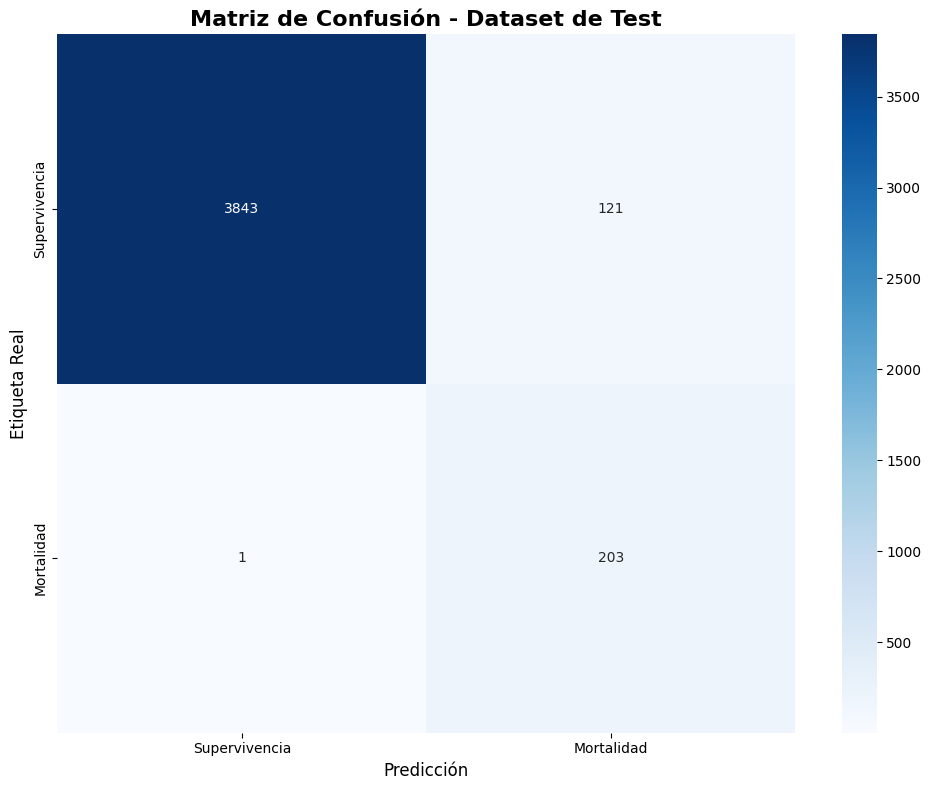


📊 MATRIZ DE CONFUSIÓN:
  • True Negatives (TN):  3843 - Correctamente predijo supervivencia
  • False Positives (FP): 121 - Falsa alarma de mortalidad
  • False Negatives (FN): 1 - No detectó mortalidad (¡CRÍTICO!)
  • True Positives (TP):  203 - Correctamente predijo mortalidad

📈 TASAS:
  • Tasa de Verdaderos Positivos (Sensitivity/Recall): 0.9951
  • Tasa de Verdaderos Negativos (Specificity):        0.9695
  • Tasa de Falsos Positivos (FPR):                    0.0305
  • Tasa de Falsos Negativos (FNR):                    0.0049


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular matriz de confusión
cm = confusion_matrix(test_labels_arr, test_preds_binary)

# Visualizar matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Supervivencia', 'Mortalidad'],
            yticklabels=['Supervivencia', 'Mortalidad'])
plt.title('Matriz de Confusión - Dataset de Test', fontsize=16, fontweight='bold')
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Predicción', fontsize=12)
plt.tight_layout()
plt.show()

# Imprimir valores de la matriz
TN, FP, FN, TP = cm.ravel()
print(f"\n📊 MATRIZ DE CONFUSIÓN:")
print(f"  • True Negatives (TN):  {TN} - Correctamente predijo supervivencia")
print(f"  • False Positives (FP): {FP} - Falsa alarma de mortalidad")
print(f"  • False Negatives (FN): {FN} - No detectó mortalidad (¡CRÍTICO!)")
print(f"  • True Positives (TP):  {TP} - Correctamente predijo mortalidad")

# Calcular tasas
print(f"\n📈 TASAS:")
print(f"  • Tasa de Verdaderos Positivos (Sensitivity/Recall): {TP/(TP+FN):.4f}")
print(f"  • Tasa de Verdaderos Negativos (Specificity):        {TN/(TN+FP):.4f}")
print(f"  • Tasa de Falsos Positivos (FPR):                    {FP/(FP+TN):.4f}")
print(f"  • Tasa de Falsos Negativos (FNR):                    {FN/(FN+TP):.4f}")

## 6 - CURVA ROC (Receiver Operating Characteristic)

La curva ROC muestra el balance entre sensibilidad y especificidad a diferentes umbrales.

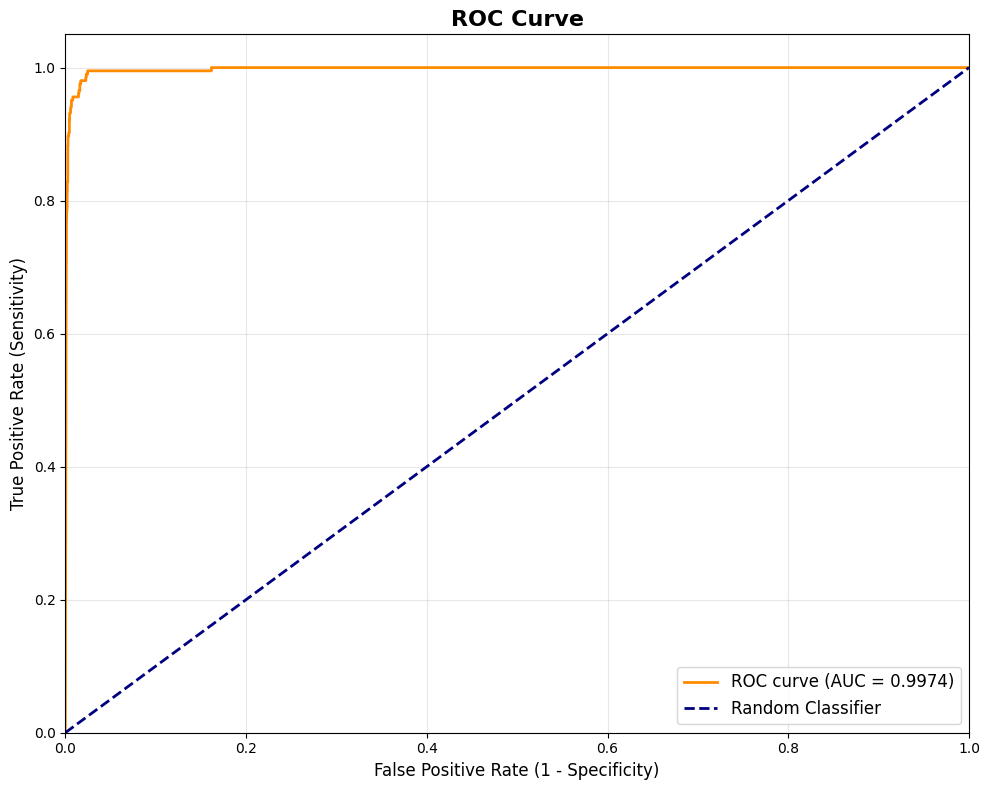


🎯 MEJOR UMBRAL DE DECISIÓN:
  • Threshold óptimo:      0.8790
  • TPR (Sensitivity):     0.9902
  • FPR:                   0.0232
  • Specificity:           0.9768


In [35]:
from sklearn.metrics import roc_curve

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(test_labels_arr, test_preds_arr)

# Graficar curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Encontrar el mejor threshold (punto más cercano a (0,1))
distances = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)
best_threshold_idx = np.argmin(distances)
best_threshold = thresholds[best_threshold_idx]

print(f"\n🎯 MEJOR UMBRAL DE DECISIÓN:")
print(f"  • Threshold óptimo:      {best_threshold:.4f}")
print(f"  • TPR (Sensitivity):     {tpr[best_threshold_idx]:.4f}")
print(f"  • FPR:                   {fpr[best_threshold_idx]:.4f}")
print(f"  • Specificity:           {1 - fpr[best_threshold_idx]:.4f}")

## 7 - CURVA PRECISION-RECALL

Especialmente útil para datasets desbalanceados. Muestra el trade-off entre precisión y recall.

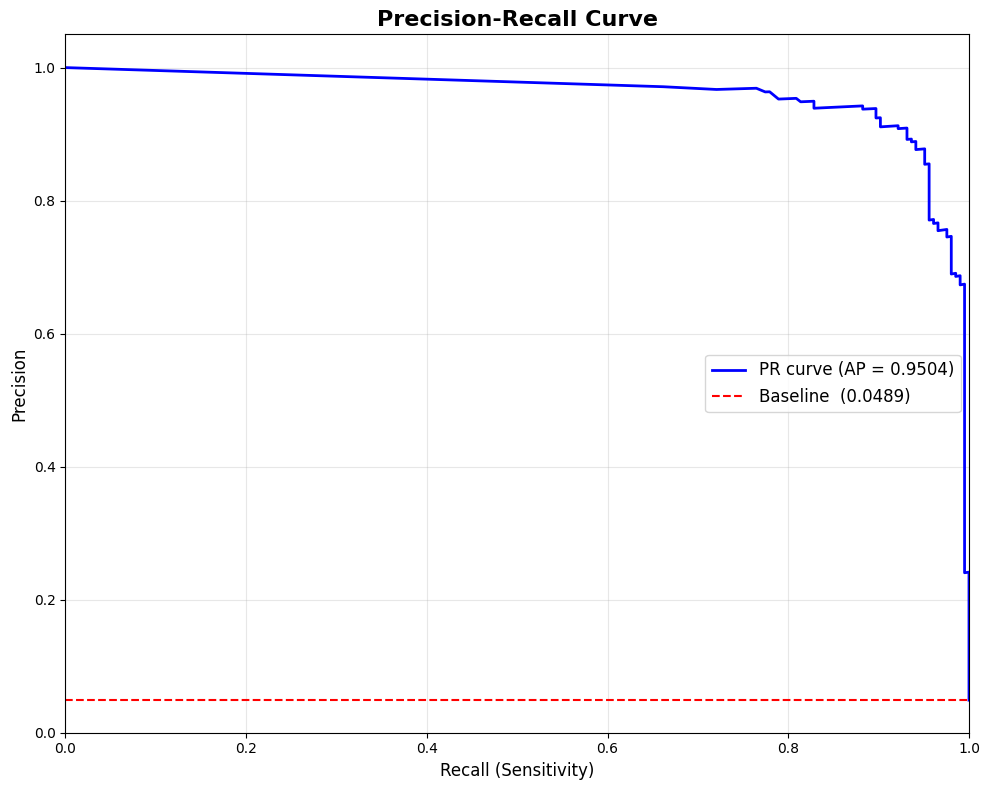


📊 ANÁLISIS PRECISION-RECALL:
  • Average Precision (AP): 0.9504
  • Prevalencia (baseline):  0.0489


In [38]:
from sklearn.metrics import precision_recall_curve

# Calcular curva Precision-Recall
precision, recall, pr_thresholds = precision_recall_curve(test_labels_arr, test_preds_arr)

# Graficar curva Precision-Recall
plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.4f})')
plt.axhline(y=test_labels_arr.mean(), color='red', linestyle='--', 
            label=f'Baseline  ({test_labels_arr.mean():.4f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=16, fontweight='bold')
plt.legend(loc="best", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 ANÁLISIS PRECISION-RECALL:")
print(f"  • Average Precision (AP): {avg_precision:.4f}")
print(f"  • Prevalencia (baseline):  {test_labels_arr.mean():.4f}")

## 8 - DISTRIBUCIÓN DE PREDICCIONES

Analiza la distribución de las probabilidades predichas por el modelo.

/var/folders/l3/zt3kw8c15v7g5vcrf88k3tfw0000gn/T/ipykernel_85163/1681269540.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([test_preds_arr[test_labels_arr == 0], test_preds_arr[test_labels_arr == 1]],


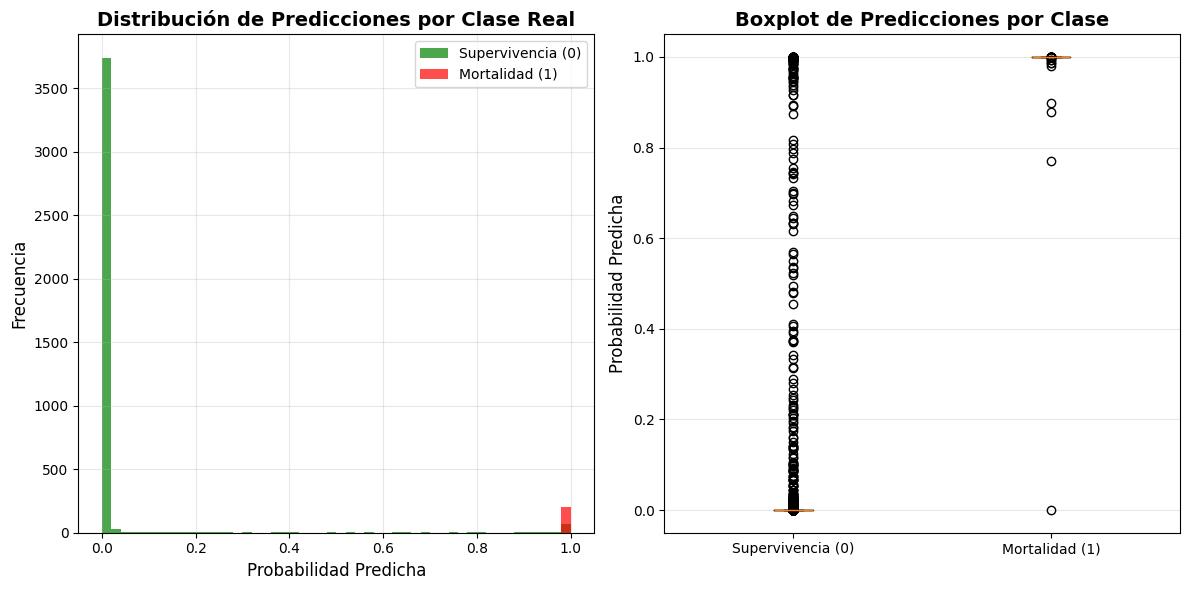


📊 ESTADÍSTICAS DE PREDICCIONES:

  Clase 0 (Supervivencia):
    - Media:     0.0320
    - Mediana:   0.0000
    - Std:       0.1610

  Clase 1 (Mortalidad):
    - Media:     0.9926
    - Mediana:   1.0000
    - Std:       0.0723


In [30]:
# Distribución de predicciones por clase real
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(test_preds_arr[test_labels_arr == 0], bins=50, alpha=0.7, color='green', label='Supervivencia (0)')
plt.hist(test_preds_arr[test_labels_arr == 1], bins=50, alpha=0.7, color='red', label='Mortalidad (1)')
plt.xlabel('Probabilidad Predicha', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Distribución de Predicciones por Clase Real', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot([test_preds_arr[test_labels_arr == 0], test_preds_arr[test_labels_arr == 1]],
            labels=['Supervivencia (0)', 'Mortalidad (1)'])
plt.ylabel('Probabilidad Predicha', fontsize=12)
plt.title('Boxplot de Predicciones por Clase', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Estadísticas de distribución
print(f"\n📊 ESTADÍSTICAS DE PREDICCIONES:")
print(f"\n  Clase 0 (Supervivencia):")
print(f"    - Media:     {test_preds_arr[test_labels_arr == 0].mean():.4f}")
print(f"    - Mediana:   {np.median(test_preds_arr[test_labels_arr == 0]):.4f}")
print(f"    - Std:       {test_preds_arr[test_labels_arr == 0].std():.4f}")

print(f"\n  Clase 1 (Mortalidad):")
print(f"    - Media:     {test_preds_arr[test_labels_arr == 1].mean():.4f}")
print(f"    - Mediana:   {np.median(test_preds_arr[test_labels_arr == 1]):.4f}")
print(f"    - Std:       {test_preds_arr[test_labels_arr == 1].std():.4f}")

## 9 - ANÁLISIS DE ERRORES

Identificamos los casos en los que el modelo se equivocó más gravemente.

In [31]:
# Calcular errores absolutos
errors = np.abs(test_labels_arr - test_preds_arr)

# Identificar falsos positivos y falsos negativos
false_positives_idx = np.where((test_labels_arr == 0) & (test_preds_binary == 1))[0]
false_negatives_idx = np.where((test_labels_arr == 1) & (test_preds_binary == 0))[0]

print("="*60)
print("ANÁLISIS DE ERRORES")
print("="*60)

print(f"\n❌ FALSOS POSITIVOS (predijo mortalidad cuando sobrevivió):")
print(f"  • Total: {len(false_positives_idx)}")
if len(false_positives_idx) > 0:
    print(f"  • Probabilidades predichas (top 10):")
    top_fp = sorted([(i, test_preds_arr[i]) for i in false_positives_idx], key=lambda x: x[1], reverse=True)[:10]
    for idx, prob in top_fp:
        print(f"    - Muestra {idx}: {prob:.4f}")

print(f"\n❌ FALSOS NEGATIVOS (NO detectó mortalidad cuando murió) - ¡MÁS CRÍTICO!:")
print(f"  • Total: {len(false_negatives_idx)}")
if len(false_negatives_idx) > 0:
    print(f"  • Probabilidades predichas (top 10 con menor probabilidad):")
    top_fn = sorted([(i, test_preds_arr[i]) for i in false_negatives_idx], key=lambda x: x[1])[:10]
    for idx, prob in top_fn:
        print(f"    - Muestra {idx}: {prob:.4f}")

# Errores más grandes
print(f"\n🔍 MAYORES ERRORES (top 10):")
largest_errors_idx = np.argsort(errors)[-10:][::-1]
for idx in largest_errors_idx:
    print(f"  • Muestra {idx}: Real={test_labels_arr[idx]:.0f}, Pred={test_preds_arr[idx]:.4f}, Error={errors[idx]:.4f}")

ANÁLISIS DE ERRORES

❌ FALSOS POSITIVOS (predijo mortalidad cuando sobrevivió):
  • Total: 121
  • Probabilidades predichas (top 10):
    - Muestra 102: 1.0000
    - Muestra 511: 1.0000
    - Muestra 1768: 1.0000
    - Muestra 2878: 1.0000
    - Muestra 912: 1.0000
    - Muestra 2959: 1.0000
    - Muestra 2046: 1.0000
    - Muestra 1494: 1.0000
    - Muestra 983: 1.0000
    - Muestra 3940: 1.0000

❌ FALSOS NEGATIVOS (NO detectó mortalidad cuando murió) - ¡MÁS CRÍTICO!:
  • Total: 1
  • Probabilidades predichas (top 10 con menor probabilidad):
    - Muestra 158: 0.0000

🔍 MAYORES ERRORES (top 10):
  • Muestra 511: Real=0, Pred=1.0000, Error=1.0000
  • Muestra 102: Real=0, Pred=1.0000, Error=1.0000
  • Muestra 2878: Real=0, Pred=1.0000, Error=1.0000
  • Muestra 1768: Real=0, Pred=1.0000, Error=1.0000
  • Muestra 912: Real=0, Pred=1.0000, Error=1.0000
  • Muestra 2959: Real=0, Pred=1.0000, Error=1.0000
  • Muestra 2046: Real=0, Pred=1.0000, Error=1.0000
  • Muestra 1494: Real=0, Pred=1.00

## 10 - CALIBRACIÓN DEL MODELO

Verifica si las probabilidades predichas están bien calibradas (si una predicción de 0.7 realmente ocurre el 70% de las veces).

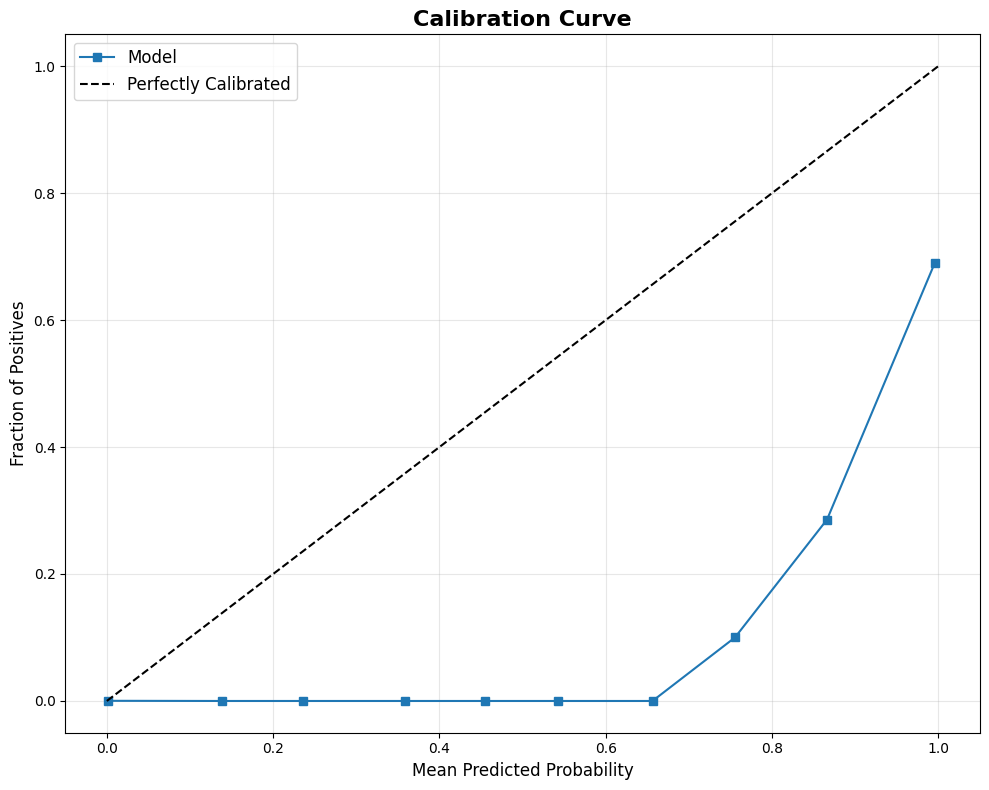


📊 CALIBRACIÓN DEL MODELO:
  • Brier Score: 0.0259 (0 = perfecto, 1 = peor)
  • Interpretación: Buena calibración


In [40]:
from sklearn.calibration import calibration_curve

# Calcular curva de calibración
fraction_of_positives, mean_predicted_value = calibration_curve(
    test_labels_arr, test_preds_arr, n_bins=10, strategy='uniform'
)

# Graficar curva de calibración
plt.figure(figsize=(10, 8))
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Model")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
plt.xlabel("Mean Predicted Probability", fontsize=12)
plt.ylabel("Fraction of Positives", fontsize=12)
plt.title("Calibration Curve", fontsize=16, fontweight='bold')
plt.legend(loc="best", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calcular Brier Score (métrica de calibración)
from sklearn.metrics import brier_score_loss
brier_score = brier_score_loss(test_labels_arr, test_preds_arr)

print(f"\n📊 CALIBRACIÓN DEL MODELO:")
print(f"  • Brier Score: {brier_score:.4f} (0 = perfecto, 1 = peor)")
print(f"  • Interpretación: {'Buena calibración' if brier_score < 0.1 else 'Calibración moderada' if brier_score < 0.25 else 'Mala calibración'}")

## 11 - RESUMEN FINAL

Resumen ejecutivo de todos los resultados.

In [33]:
print("="*70)
print("       RESUMEN EJECUTIVO - EVALUACIÓN EN DATASET DE TEST")
print("="*70)

print(f"\n📁 INFORMACIÓN DEL MODELO:")
print(f"  • Modelo evaluado: {model_path}")
print(f"  • Arquitectura: ECGNet (CNN)")
print(f"  • Parámetros: {sum(p.numel() for p in model.parameters()):,}")

print(f"\n📊 DATOS DE TEST:")
print(f"  • Total de muestras: {len(test_labels_arr)}")
print(f"  • Casos de mortalidad: {test_labels_arr.sum():.0f} ({100*test_labels_arr.mean():.2f}%)")
print(f"  • Casos de supervivencia: {(len(test_labels_arr) - test_labels_arr.sum()):.0f} ({100*(1-test_labels_arr.mean()):.2f}%)")

print(f"\n🎯 MÉTRICAS PRINCIPALES:")
print(f"  • AUC-ROC:                {auc_roc:.4f}")
print(f"  • Accuracy:               {accuracy:.4f}")
print(f"  • Balanced Accuracy:      {balanced_acc:.4f}")
print(f"  • F1-Score (Macro):       {f1_macro:.4f}")
print(f"  • Average Precision:      {avg_precision:.4f}")
print(f"  • Matthews CC:            {mcc:.4f}")
print(f"  • Brier Score:            {brier_score:.4f}")

print(f"\n📈 RENDIMIENTO POR CLASE:")
print(f"  Supervivencia (Clase 0):")
print(f"    - Precision: {precision_per_class[0]:.4f}")
print(f"    - Recall:    {recall_per_class[0]:.4f}")
print(f"    - F1-Score:  {f1_per_class[0]:.4f}")
print(f"  Mortalidad (Clase 1):")
print(f"    - Precision: {precision_per_class[1]:.4f}")
print(f"    - Recall:    {recall_per_class[1]:.4f}")
print(f"    - F1-Score:  {f1_per_class[1]:.4f}")

print(f"\n⚠️  ERRORES:")
print(f"  • Falsos Positivos: {FP} ({100*FP/(FP+TN):.2f}%)")
print(f"  • Falsos Negativos: {FN} ({100*FN/(FN+TP):.2f}%) - ¡CRÍTICOS!")

print(f"\n✅ ACIERTOS:")
print(f"  • Verdaderos Negativos: {TN}")
print(f"  • Verdaderos Positivos: {TP}")

print(f"\n💡 INTERPRETACIÓN:")
if auc_roc >= 0.9:
    print(f"  • Excelente discriminación (AUC ≥ 0.9)")
elif auc_roc >= 0.8:
    print(f"  • Buena discriminación (AUC ≥ 0.8)")
elif auc_roc >= 0.7:
    print(f"  • Discriminación aceptable (AUC ≥ 0.7)")
else:
    print(f"  • Discriminación pobre (AUC < 0.7)")

if recall_per_class[1] >= 0.8:
    print(f"  • Buena detección de mortalidad (Recall ≥ 0.8)")
elif recall_per_class[1] >= 0.7:
    print(f"  • Detección aceptable de mortalidad (Recall ≥ 0.7)")
else:
    print(f"  • Detección insuficiente de mortalidad (Recall < 0.7)")

print("\n" + "="*70)

       RESUMEN EJECUTIVO - EVALUACIÓN EN DATASET DE TEST

📁 INFORMACIÓN DEL MODELO:
  • Modelo evaluado: MODELS/M9/ecg_mortality_model.pth
  • Arquitectura: ECGNet (CNN)
  • Parámetros: 38,305

📊 DATOS DE TEST:
  • Total de muestras: 4168
  • Casos de mortalidad: 204 (4.89%)
  • Casos de supervivencia: 3964 (95.11%)

🎯 MÉTRICAS PRINCIPALES:
  • AUC-ROC:                0.9974
  • Accuracy:               0.9707
  • Balanced Accuracy:      0.9823
  • F1-Score (Macro):       0.8767
  • Average Precision:      0.9504
  • Matthews CC:            0.7772
  • Brier Score:            0.0259

📈 RENDIMIENTO POR CLASE:
  Supervivencia (Clase 0):
    - Precision: 0.9997
    - Recall:    0.9695
    - F1-Score:  0.9844
  Mortalidad (Clase 1):
    - Precision: 0.6265
    - Recall:    0.9951
    - F1-Score:  0.7689

⚠️  ERRORES:
  • Falsos Positivos: 121 (3.05%)
  • Falsos Negativos: 1 (0.49%) - ¡CRÍTICOS!

✅ ACIERTOS:
  • Verdaderos Negativos: 3843
  • Verdaderos Positivos: 203

💡 INTERPRETACIÓN:
  • E

## 12 - GUARDAR RESULTADOS (OPCIONAL)

Guarda los resultados de la evaluación para referencia futura.

In [34]:
import pandas as pd
import json
from datetime import datetime

# Crear diccionario con todos los resultados
results = {
    'model_path': model_path,
    'evaluation_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_info': {
        'total_samples': len(test_labels_arr),
        'mortality_cases': int(test_labels_arr.sum()),
        'mortality_rate': float(test_labels_arr.mean())
    },
    'metrics': {
        'auc_roc': float(auc_roc),
        'accuracy': float(accuracy),
        'balanced_accuracy': float(balanced_acc),
        'average_precision': float(avg_precision),
        'f1_macro': float(f1_macro),
        'f1_weighted': float(f1_weighted),
        'matthews_cc': float(mcc),
        'brier_score': float(brier_score),
        'best_threshold': float(best_threshold)
    },
    'per_class_metrics': {
        'class_0_survival': {
            'precision': float(precision_per_class[0]),
            'recall': float(recall_per_class[0]),
            'f1_score': float(f1_per_class[0])
        },
        'class_1_mortality': {
            'precision': float(precision_per_class[1]),
            'recall': float(recall_per_class[1]),
            'f1_score': float(f1_per_class[1])
        }
    },
    'confusion_matrix': {
        'true_negatives': int(TN),
        'false_positives': int(FP),
        'false_negatives': int(FN),
        'true_positives': int(TP)
    }
}

# Guardar como JSON
output_path = model_path.replace('.pth', '_test_results.json')
with open(output_path, 'w') as f:
    json.dump(results, f, indent=4)

print(f"✓ Resultados guardados en: {output_path}")

# Guardar predicciones (opcional, puede ser un archivo grande)
predictions_df = pd.DataFrame({
    'true_label': test_labels_arr,
    'predicted_probability': test_preds_arr,
    'predicted_class': test_preds_binary
})

predictions_path = model_path.replace('.pth', '_test_predictions.csv')
predictions_df.to_csv(predictions_path, index=False)

print(f"✓ Predicciones guardadas en: {predictions_path}")

✓ Resultados guardados en: MODELS/M9/ecg_mortality_model_test_results.json
✓ Predicciones guardadas en: MODELS/M9/ecg_mortality_model_test_predictions.csv
